In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering


In [2]:
df = pd.read_csv("Mall_Customers.csv")
df.head()


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



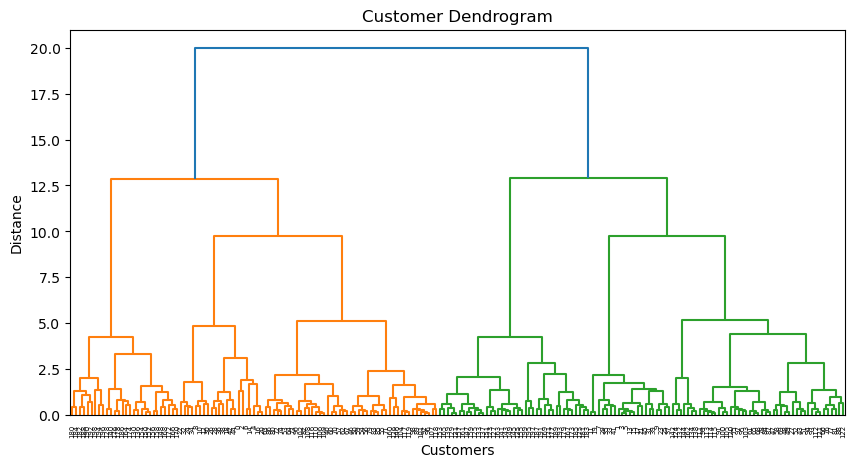

In [5]:
plt.figure(figsize=(10, 5))
linked = linkage(X_scaled, method="ward")

dendrogram(linked)
plt.title("Customer Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()


In [6]:
model = AgglomerativeClustering(n_clusters=4)
clusters = model.fit_predict(X_scaled)

df["Cluster"] = clusters


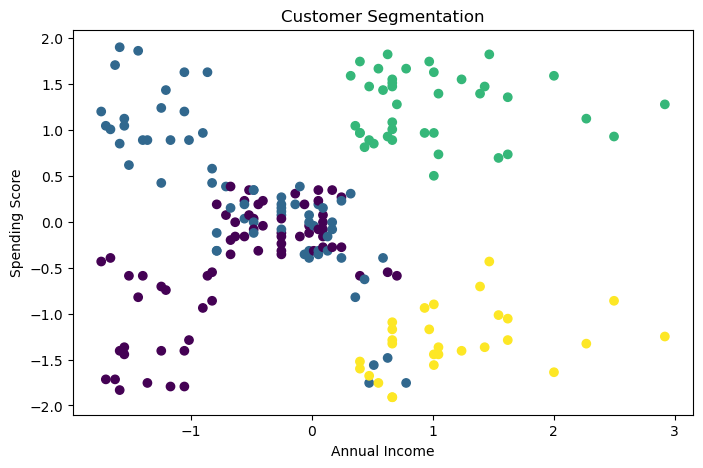

In [7]:
plt.figure(figsize=(8, 5))
plt.scatter(
    X_scaled[:, 1],
    X_scaled[:, 2],
    c=clusters
)
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Customer Segmentation")
plt.show()
